# **Reto SURA: Determinación de Tamaño Muestral, Sondeo de Limpieza Inicial de Variables para el Dataset de Tareas y Ejercicios Prueba de Clustering**

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install --upgrade protobuf

import google.protobuf

print(google.protobuf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.6
    Uninstalling protobuf-6.33.6:
      Successfully uninstalled protobuf-6.33.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.80.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 7.34.1 which is incompatible.
google-colabsqlviz 0.2.13 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 7.34.1 which is incompatible.
googleapis-common-protos 1.73.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-logging 3.14.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0

7.34.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sentence_transformers import SentenceTransformer
import umap
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import torch

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
print(torch.cuda.is_available())

False


# Convenciones de Datasets

* **df** → Dataset limpio y normalizado con 13 columnas.

* **df1** → Dataset limpio y normalizado y procesado con OneHotEnconding (dummies).

* **df2** → Dataset con embeddings con 389 columnas (4 numéricas, 1 de texto sin importancia, 384 dimensiones del modelo all-MiniLM L6 v2).

* **df3** → Dataset normalizado dummies + PCA (df1 + PCA)

* **df4** → Dataset con embeddings + PCA (df2 + PCA)

* **df5** → Dataset con embeddings + UMAP (df2 + UMAP)

* **df6** → Dataset normalizado dummies + UMAP (df1 + UMAP)

# 1.0. Cálculo de Tamaño de Muestra por Proporciones y Cálculo del Error para 15.000 registros

In [5]:
# Carga de datos

df = pd.read_csv("tareas_sample.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NMCONSECUTIVO_ORDEN          15000 non-null  int64  
 1   NMCONSECUTIVO_PLAN           15000 non-null  int64  
 2   NMACTIVIDAD                  15000 non-null  int64  
 3   NMVERSION                    15000 non-null  int64  
 4   DNI_DISTRIBUIDOR             15000 non-null  object 
 5   NOMBRE_DISTRIBUIDOR          15000 non-null  object 
 6   DNI_PRESTADOR                15000 non-null  object 
 7   NOMBRE_PRESTADOR             15000 non-null  object 
 8   TIPO_DE_ASESOR               14949 non-null  object 
 9   DNI_EMPRESA                  15000 non-null  object 
 10  DSNOMBRE_EMPRESA             15000 non-null  object 
 11  NPOLIZA                      15000 non-null  object 
 12  CDSUCURSAL_ENTREGA           14975 non-null  object 
 13  CDTAREA         

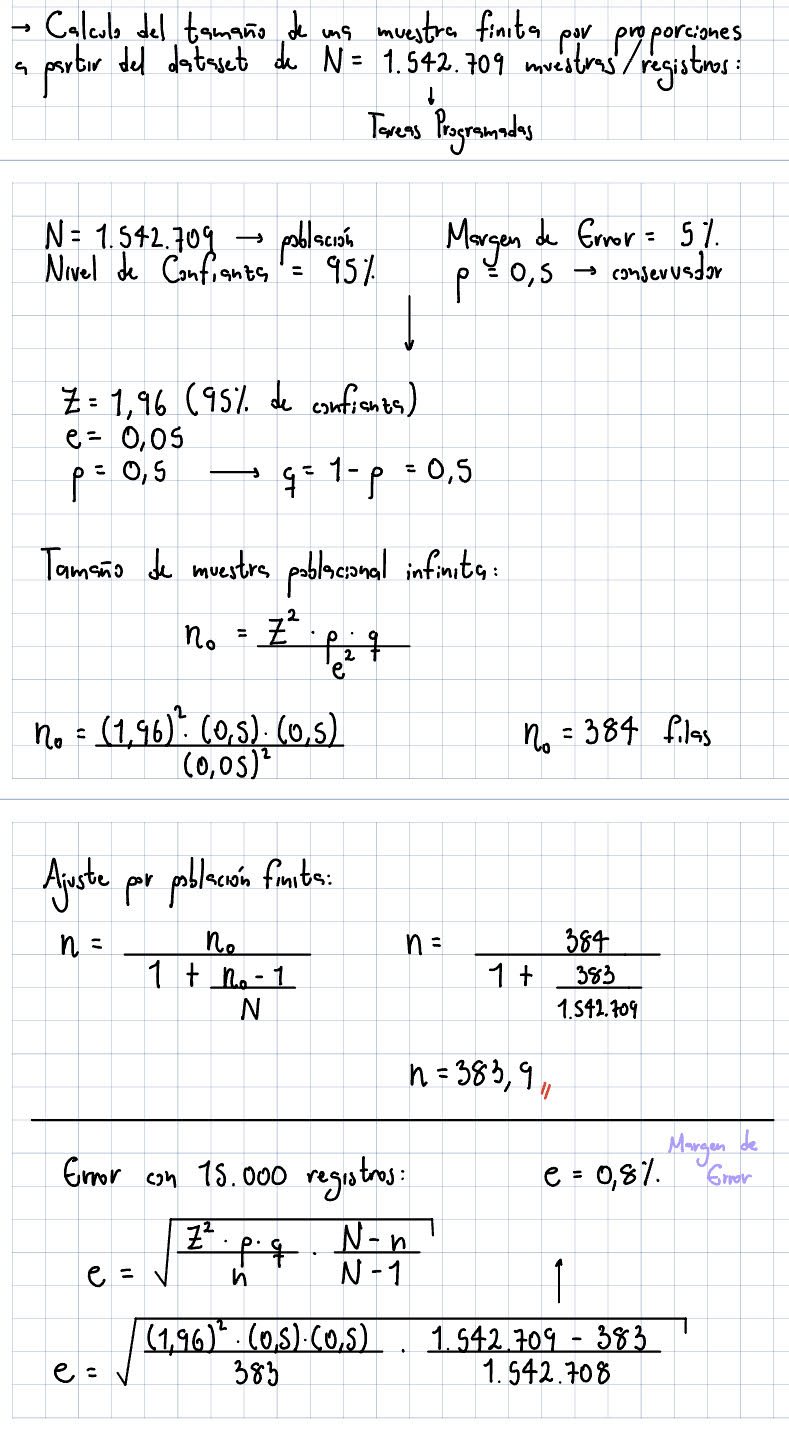

# 2.0. Completitud en las Columnas

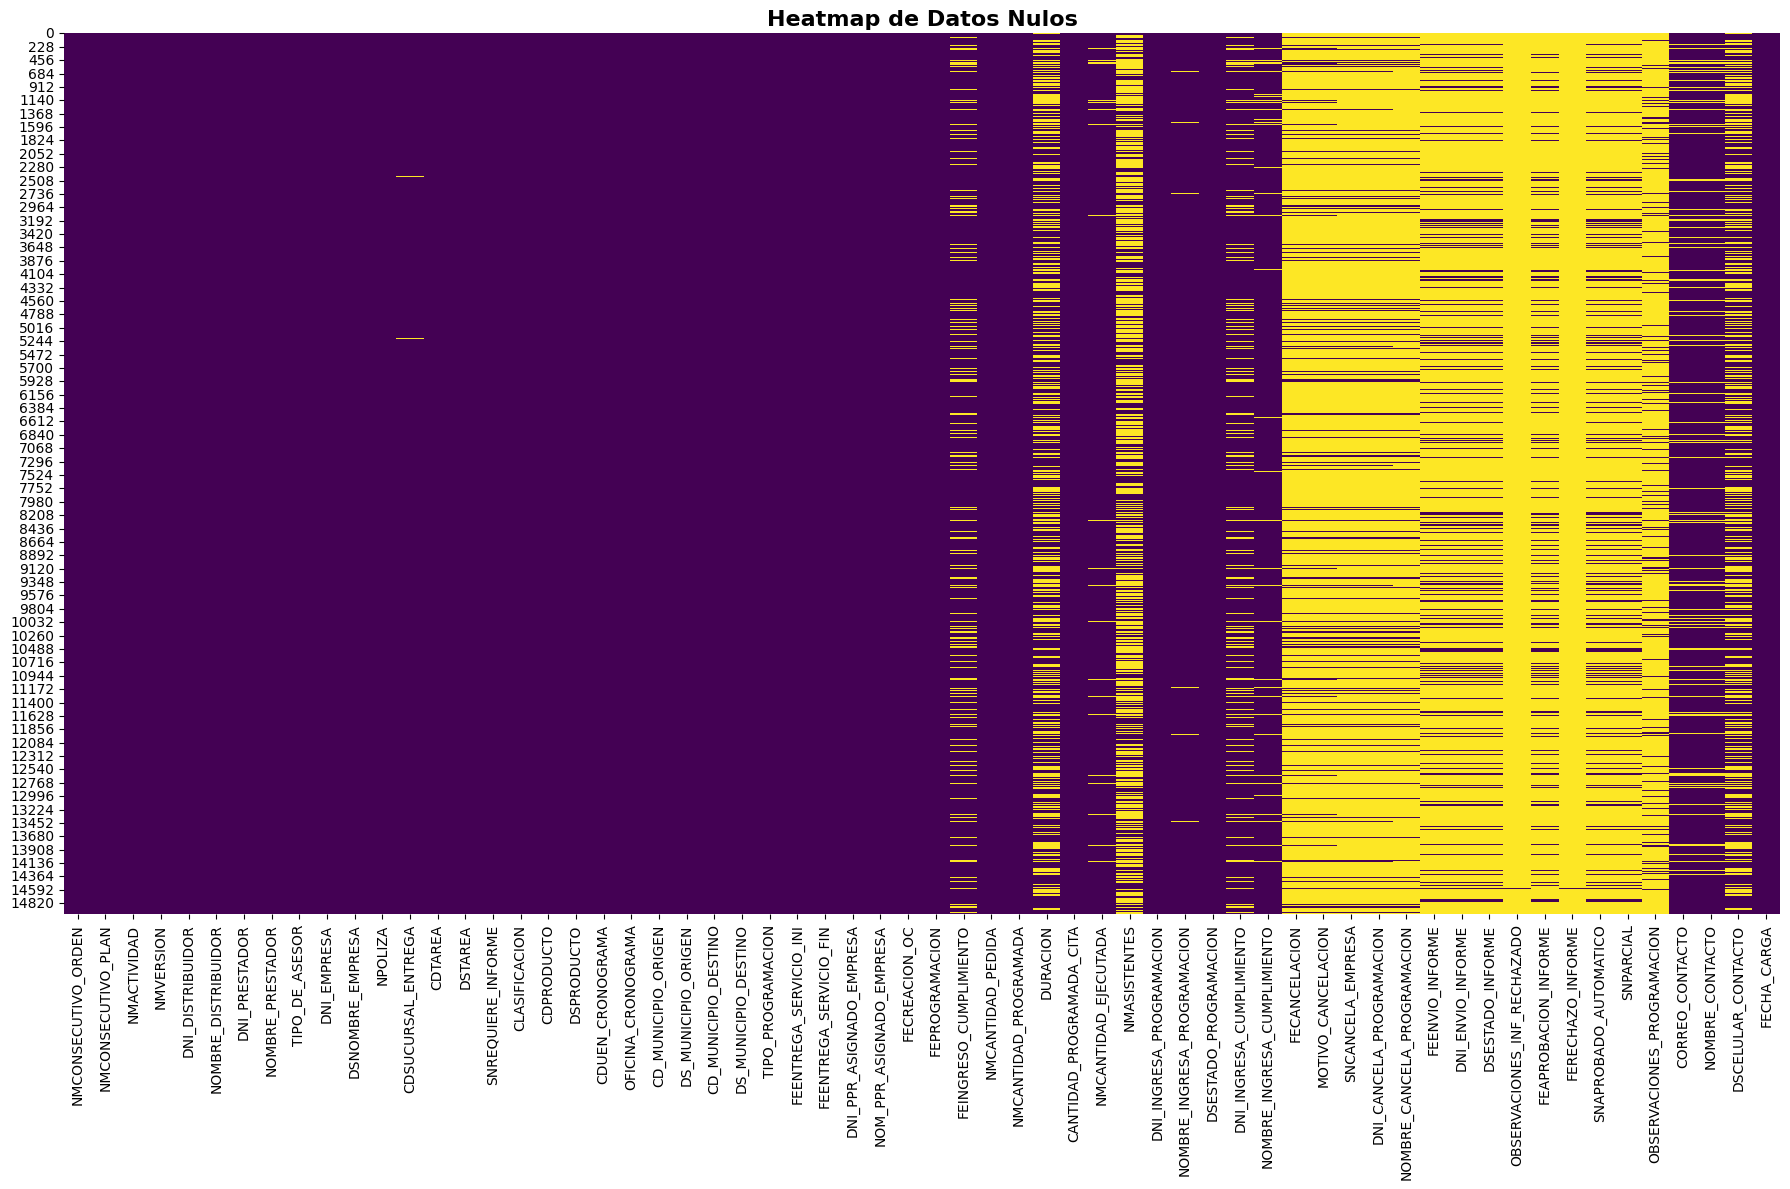

In [6]:
# Heatmap de Datos Nulos

plt.figure(figsize = (18, 12))

sns.heatmap(df.isnull(), cbar = False, cmap = 'viridis')
plt.title('Heatmap de Datos Nulos', fontsize = 16, fontweight = 'bold')
plt.tight_layout()

plt.show()

In [7]:
# Porcentaje de nulos por columnas

for col in df.columns:

    print("El porcentaje de nulos en la columna ", col, "es: ", round(df[col].isnull().mean() * 100, 2), "%")

El porcentaje de nulos en la columna  NMCONSECUTIVO_ORDEN es:  0.0 %
El porcentaje de nulos en la columna  NMCONSECUTIVO_PLAN es:  0.0 %
El porcentaje de nulos en la columna  NMACTIVIDAD es:  0.0 %
El porcentaje de nulos en la columna  NMVERSION es:  0.0 %
El porcentaje de nulos en la columna  DNI_DISTRIBUIDOR es:  0.0 %
El porcentaje de nulos en la columna  NOMBRE_DISTRIBUIDOR es:  0.0 %
El porcentaje de nulos en la columna  DNI_PRESTADOR es:  0.0 %
El porcentaje de nulos en la columna  NOMBRE_PRESTADOR es:  0.0 %
El porcentaje de nulos en la columna  TIPO_DE_ASESOR es:  0.34 %
El porcentaje de nulos en la columna  DNI_EMPRESA es:  0.0 %
El porcentaje de nulos en la columna  DSNOMBRE_EMPRESA es:  0.0 %
El porcentaje de nulos en la columna  NPOLIZA es:  0.0 %
El porcentaje de nulos en la columna  CDSUCURSAL_ENTREGA es:  0.17 %
El porcentaje de nulos en la columna  CDTAREA es:  0.0 %
El porcentaje de nulos en la columna  DSTAREA es:  0.0 %
El porcentaje de nulos en la columna  SNREQUIER

# 3.0. Eliminación de Columnas

# 3.1. Columnas que sobrepasan Umbral de Eliminación

In [8]:
# Eliminar columnas con umbral por encima de 10%

umbral = 0.1
cols_eliminar = []

for col in df.columns:

  if df[col].isnull().sum() / len(df) > umbral:

    cols_eliminar.append(col)

print(cols_eliminar)
print(len(cols_eliminar))

df = df.drop(cols_eliminar, axis = 1)

['FEINGRESO_CUMPLIMIENTO', 'DURACION', 'NMASISTENTES', 'DNI_INGRESA_CUMPLIMIENTO', 'FECANCELACION', 'MOTIVO_CANCELACION', 'SNCANCELA_EMPRESA', 'DNI_CANCELA_PROGRAMACION', 'NOMBRE_CANCELA_PROGRAMACION', 'FEENVIO_INFORME', 'DNI_ENVIO_INFORME', 'DSESTADO_INFORME', 'OBSERVACIONES_INF_RECHAZADO', 'FEAPROBACION_INFORME', 'FERECHAZO_INFORME', 'SNAPROBADO_AUTOMATICO', 'SNPARCIAL', 'OBSERVACIONES_PROGRAMACION', 'CORREO_CONTACTO', 'NOMBRE_CONTACTO', 'DSCELULAR_CONTACTO']
21


Al contar el la cantidad de nulos (como porcentaje de la columnas), se pueden eliminar las siguientes columnas:

['FEINGRESO_CUMPLIMIENTO', 'DURACION', 'NMASISTENTES', 'DNI_INGRESA_CUMPLIMIENTO', 'FECANCELACION', 'MOTIVO_CANCELACION', 'SNCANCELA_EMPRESA', 'DNI_CANCELA_PROGRAMACION', 'NOMBRE_CANCELA_PROGRAMACION', 'FEENVIO_INFORME', 'DNI_ENVIO_INFORME', 'DSESTADO_INFORME', 'OBSERVACIONES_INF_RECHAZADO', 'FEAPROBACION_INFORME', 'FERECHAZO_INFORME', 'SNAPROBADO_AUTOMATICO', 'SNPARCIAL', 'OBSERVACIONES_PROGRAMACION', 'CORREO_CONTACTO', 'NOMBRE_CONTACTO', 'DSCELULAR_CONTACTO']

In [9]:
# Que quedó?

df.sample(5)

,NMCONSECUTIVO_ORDEN,NMCONSECUTIVO_PLAN,NMACTIVIDAD,NMVERSION,DNI_DISTRIBUIDOR,NOMBRE_DISTRIBUIDOR,DNI_PRESTADOR,NOMBRE_PRESTADOR,TIPO_DE_ASESOR,DNI_EMPRESA,...,FEPROGRAMACION,NMCANTIDAD_PEDIDA,NMCANTIDAD_PROGRAMADA,CANTIDAD_PROGRAMADA_CITA,NMCANTIDAD_EJECUTADA,DNI_INGRESA_PROGRAMACION,NOMBRE_INGRESA_PROGRAMACION,DSESTADO_PROGRAMACION,NOMBRE_INGRESA_CUMPLIMIENTO,FECHA_CARGA
3854,8437103,1886919,167,2,e7276191a5,1c0743ab6a,d61926a794,5712a46f62,ASESOR EN RIESGOS - ASESOR EN PREVENCIÓN,536360cce4,...,2025-12-12T08:00:00.000Z,30.0,0.0,8.0,0.0,ae25f372fd,abd58e3070,CITA CANCELADA,abd58e3070,2026-01-06
396,9523322,1964831,172,1,eedaeb666f,14c4065f82,59f05cdd49,3145393fc2,ASESOR EN PREVENCIÓN,3c752668eb,...,2025-11-06T00:00:00.000Z,27.0,0.0,6.0,6.0,82f133906a,c3ebe6eb03,CITA EJECUTADA,c3ebe6eb03,2026-01-06
14749,9228291,944443,5,1,474d531160,b5f53e93b5,18419b2ffd,6c3be30166,ASESOR PREVENCION SEGMENTO 1 Y 2,0a9252a1ab,...,2025-07-03T07:00:00.000Z,4.0,0.0,2.0,2.0,18419b2ffd,6c3be30166,CITA EJECUTADA,6c3be30166,2026-01-06
8391,9506907,103814,156,12,8fa2c5e0e0,087d02c7f5,99769c4972,cbdb2dd3c2,ASIGNADO - ASESOR EN RIESGOS - ASESOR EN PREVE...,dbb2f92ed7,...,2025-11-22T09:00:00.000Z,30.0,0.0,1.0,1.0,d5fc510544,b63169ccab,CITA EJECUTADA,b63169ccab,2026-01-06
1484,9085186,26586,161,19,53c08e5412,7cc0573dee,4f4c14dcca,4c696beba9,ASESOR EN PREVENCIÓN,b995934bf7,...,2025-06-10T07:00:00.000Z,68.0,0.0,10.0,10.0,4f4c14dcca,4c696beba9,CITA EJECUTADA,4c696beba9,2026-01-06


# 3.2. Columnas Innecesarias

In [10]:
# Eliminar columnas innecesarias

cols_innecesarias = ["NMCONSECUTIVO_ORDEN", "NMCONSECUTIVO_PLAN", "NMACTIVIDAD",
                     "NMVERSION", "NOMBRE_DISTRIBUIDOR", "NOMBRE_PRESTADOR",
                     "DSNOMBRE_EMPRESA", "NPOLIZA", "CDSUCURSAL_ENTREGA",
                     "CDTAREA", "CDPRODUCTO", "CDUEN_CRONOGRAMA",
                     "OFICINA_CRONOGRAMA", "CD_MUNICIPIO_ORIGEN", "CD_MUNICIPIO_DESTINO",
                     "DNI_PPR_ASIGNADO_EMPRESA", "NOM_PPR_ASIGNADO_EMPRESA", "DNI_INGRESA_PROGRAMACION",
                     "NOMBRE_INGRESA_PROGRAMACION", "NOMBRE_INGRESA_CUMPLIMIENTO", "FECHA_CARGA",
                     "FEENTREGA_SERVICIO_INI", "FEENTREGA_SERVICIO_FIN", "FECREACION_OC",
                     "FEPROGRAMACION"]

len(cols_innecesarias)

25

Por insignificancia, reglas de analítica de datos y comprobación con el diccionario de datos, se descartan:

["NMCONSECUTIVO_ORDEN", "NMCONSECUTIVO_PLAN", "NMACTIVIDAD",
                     "NMVERSION", "NOMBRE_DISTRIBUIDOR", "NOMBRE_PRESTADOR",
                     "DSNOMBRE_EMPRESA", "NPOLIZA", "CDSUCURSAL_ENTREGA",
                     "CDTAREA", "CDPRODUCTO", "CDUEN_CRONOGRAMA",
                     "OFICINA_CRONOGRAMA", "CD_MUNICIPIO_ORIGEN", "CD_MUNICIPIO_DESTINO",
                     "DNI_PPR_ASIGNADO_EMPRESA", "NOM_PPR_ASIGNADO_EMPRESA", "DNI_INGRESA_PROGRAMACION",
                     "NOMBRE_INGRESA_PROGRAMACION", "NOMBRE_INGRESA_CUMPLIMIENTO", "FECHA_CARGA"]



**Se podrían dejan las columnas relacionadas con DNI porque pueden servir para hacer un join después**.


In [11]:
# Eliminar la lista de columnas innecesarias

df = df.drop(cols_innecesarias, axis = 1)

In [12]:
# Eliminar columnas de DNI

cols_DNI = ["DNI_DISTRIBUIDOR", "DNI_PRESTADOR", "DNI_EMPRESA"]

df = df.drop(cols_DNI, axis = 1)

In [13]:
# Dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TIPO_DE_ASESOR            14949 non-null  object 
 1   DSTAREA                   15000 non-null  object 
 2   SNREQUIERE_INFORME        15000 non-null  object 
 3   CLASIFICACION             15000 non-null  object 
 4   DSPRODUCTO                15000 non-null  object 
 5   DS_MUNICIPIO_ORIGEN       15000 non-null  object 
 6   DS_MUNICIPIO_DESTINO      15000 non-null  object 
 7   TIPO_PROGRAMACION         15000 non-null  object 
 8   NMCANTIDAD_PEDIDA         15000 non-null  float64
 9   NMCANTIDAD_PROGRAMADA     15000 non-null  float64
 10  CANTIDAD_PROGRAMADA_CITA  15000 non-null  float64
 11  NMCANTIDAD_EJECUTADA      14653 non-null  float64
 12  DSESTADO_PROGRAMACION     15000 non-null  object 
dtypes: float64(4), object(9)
memory usage: 1.5+ MB


# 4.0. Imputación

In [14]:
# Imputar la columnas "NMCANTIDAD_EJECUTADA" por KNN Imputer

imputador_knn = KNNImputer(n_neighbors = 5)

df['NMCANTIDAD_EJECUTADA'] = imputador_knn.fit_transform(df[['NMCANTIDAD_EJECUTADA']])


# 5.0. Normalización

In [15]:
# Normalizar columnas numéricas con SC

sc = StandardScaler()

num_cols = df.select_dtypes(include = "float64").columns

df[num_cols] = sc.fit_transform(df[num_cols])

df.head()

,TIPO_DE_ASESOR,DSTAREA,SNREQUIERE_INFORME,CLASIFICACION,DSPRODUCTO,DS_MUNICIPIO_ORIGEN,DS_MUNICIPIO_DESTINO,TIPO_PROGRAMACION,NMCANTIDAD_PEDIDA,NMCANTIDAD_PROGRAMADA,CANTIDAD_PROGRAMADA_CITA,NMCANTIDAD_EJECUTADA,DSESTADO_PROGRAMACION
0,ASESOR EN RIESGOS,"IDENTIFICACION DE PELIGROS , EVALUACION Y VALO...",S,ASESORÍA,170-SISTEMA DE GESTIÓN EN SST,SANTIAGO DE CALI,JAMUNDI,CAMPO,0.672060,-0.069398,0.119736,0.138503,CITA EJECUTADA
1,ASESOR OPERACIONES,"ACOMPAÑAMIENTO EN PAGINA WEB, SERVICIOS EN LIN...",N,OPER. ASESORIA,GESTION ADMINISTRATIVA,BUGA,BUGA,CAMPO,-0.184774,-0.069398,-0.067405,-0.049027,CITA EJECUTADA
2,ASESOR EN RIESGOS,PRACTICAS SEGURAS,S,ASESORÍA,170-SISTEMA DE GESTIÓN EN SST,SANTIAGO DE CALI,YUMBO,CAMPO,0.887450,-0.069398,-0.005025,0.013483,CITA EJECUTADA
3,ASESOR EN RIESGOS,INSPECCIONES DE SEGURIDAD,S,ASESORÍA,170-SISTEMA DE GESTIÓN EN SST,SANTIAGO DE CALI,SANTIAGO DE CALI,CAMPO,0.376600,-0.069398,-0.005025,0.013483,CITA EJECUTADA
4,ASESOR EN RIESGOS - ASESOR EN PREVENCIÓN,INSPECCION DE PUESTO DE TRABAJO,S,ASESORÍA,158-PVE Y ACCIONES PARA PREVENCIÓN DE LOS EFEC...,BELLO,MEDELLIN,INFORME,0.022048,-0.069398,-0.036215,-0.017772,CITA EJECUTADA


In [16]:
df.shape

(15000, 13)

# 6.0. Adición o Cambio de Estructura para Variables

In [17]:
# Agrupar roles para la columna de Asesores

def agrupar_roles(rol):

    rol = str(rol).upper()

    # 1. Soporte, Operaciones y Atención

    if 'OPERACIONES' in rol or 'LINEA DE ATENCION' in rol:

        return 'Soporte y Operaciones'

    # 2. Otros / Especiales

    if 'ASIGNADO' in rol or 'OTRO ASESOR' in rol or 'INTEGRAL' in rol or 'HIGIENE' in rol:

        return 'Otros / Especiales'

    # Contamos cuántas áreas "Core" tiene asignadas la persona

    tiene_prevencion = 'PREVENCION' in rol or 'PREVENCIÓN' in rol
    tiene_riesgos = 'RIESGOS' in rol
    tiene_proyectos = 'PROYECTOS' in rol

    suma_areas = sum([tiene_prevencion, tiene_riesgos, tiene_proyectos])

    # 3. Roles Mixtos (si tiene más de 1 área core)

    if suma_areas >= 2:

        return 'Mixto (Core)'

    # 4. Roles puros (solo tiene 1 área)

    if tiene_prevencion:

        return 'Prevención'

    elif tiene_riesgos:

        return 'Riesgos'

    elif tiene_proyectos:

        return 'Proyectos'

    # Por defecto, si hay algo que no mapeó

    return 'Otros / Especiales'

# Agruparlo

df['ROL_ASESOR'] = df['TIPO_DE_ASESOR'].apply(agrupar_roles)

# Borra columna

df = df.drop(columns = ['TIPO_DE_ASESOR'])

In [18]:
# Ver eL value_counts

print(df['ROL_ASESOR'].value_counts())

ROL_ASESOR
Prevención               9304
Mixto (Core)             1755
Riesgos                  1722
Proyectos                1419
Soporte y Operaciones     468
Otros / Especiales        332
Name: count, dtype: int64


# 7.0. Codificación de Variables Categóricas

In [27]:
# One Hot Encoding para las categóricas

df1 = pd.get_dummies(df, drop_first = False)

df1.head()

,NMCANTIDAD_PEDIDA,NMCANTIDAD_PROGRAMADA,CANTIDAD_PROGRAMADA_CITA,NMCANTIDAD_EJECUTADA,DSTAREA_ABORDAJE DEL SG SST,"DSTAREA_ABORDAJE DEL SG SST PARA PYMES (ASESORIA EN CURSO VIRTUAL DE LAS 50 HORAS EN SST, FORMACION Y CAPACITACION, ASESORIA EN EXAMENES OCUPACIONALES, ASESORIA EN SISTEMA DE GESTION EN SEGURIDAD Y SALUD EN EL TRABAJO).",DSTAREA_ABORDAJE DE LA ESTRATEGIA DE REINTEGRO,DSTAREA_ABORDAJE DEL PVE PARA LA PREVENCION DEL RIESGO CARDIOVASCULAR,DSTAREA_ABORDAJE DEL SISTEMA DE TRABAJOS SEGURO PARA TAREAS DE ALTO RIESGO,DSTAREA_ABORDAJE PARA LA DEFINICION DE UNA RUTINA DE CALISTENIA COMO APOYO AL PVE,...,DSESTADO_PROGRAMACION_CITA PROGRAMADA,DSESTADO_PROGRAMACION_CITA REPROGRAMADA,DSESTADO_PROGRAMACION_PARCIALMENTE COMPLETADO,DSESTADO_PROGRAMACION_PARCIALMENTE EJECUTADO,ROL_ASESOR_Mixto (Core),ROL_ASESOR_Otros / Especiales,ROL_ASESOR_Prevención,ROL_ASESOR_Proyectos,ROL_ASESOR_Riesgos,ROL_ASESOR_Soporte y Operaciones
0,0.672060,-0.069398,0.119736,0.138503,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,-0.184774,-0.069398,-0.067405,-0.049027,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,0.887450,-0.069398,-0.005025,0.013483,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,0.376600,-0.069398,-0.005025,0.013483,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0.022048,-0.069398,-0.036215,-0.017772,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


**df1: Dataset imputado, normalizado, codificado**

# 8.0. Prueba: Dataset Embeddings



In [28]:
df2 = df.copy()

In [29]:
# Carga del modelo preentrenado (dimensión embeddings: 384)

# Si hay GPU:

# model = SentenceTransformer('all-MiniLM-L6-V2', device = 'cuda')

# No hay GPU:

model = SentenceTransformer('all-MiniLM-L6-V2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [30]:
# Selección de columnas string (object) --> no hay category

text_cols = df2.select_dtypes(include = 'object').columns

# Unir texto de varias columnas en una sola

df2['embeddings_texto'] = df2[text_cols].astype(str).agg(' '.join, axis = 1)

# Generarr embeddings (aca se tiene matriz donde cada fila es un vector que representa semánticamente el texto)

embeddings = model.encode(df2['embeddings_texto'].tolist(), batch_size = 64, show_progress_bar = True)

# Convertir a dataframe

embeddings_df = pd.DataFrame(embeddings, columns = [f'EMBEDDING_{i}' for i in range(embeddings.shape[1])])

# Borrar las columnas antiguas

df2 = df2.drop(text_cols, axis = 1)

# Concatenar las columnas convertidas a embeddings y las numericas

df2 = pd.concat([df2, embeddings_df], axis = 1)

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

In [31]:
print("Dimensiones del dataframe luego de embeddings:", df2.shape)

df2 = df2.drop("embeddings_texto", axis = 1)

print("--" * 30)

df2.head()

Dimensiones del dataframe luego de embeddings: (15000, 389)
------------------------------------------------------------


,NMCANTIDAD_PEDIDA,NMCANTIDAD_PROGRAMADA,CANTIDAD_PROGRAMADA_CITA,NMCANTIDAD_EJECUTADA,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,...,EMBEDDING_374,EMBEDDING_375,EMBEDDING_376,EMBEDDING_377,EMBEDDING_378,EMBEDDING_379,EMBEDDING_380,EMBEDDING_381,EMBEDDING_382,EMBEDDING_383
0,0.672060,-0.069398,0.119736,0.138503,0.051426,0.066248,-0.025755,0.026579,0.021875,-0.044474,...,0.024347,0.018448,0.096516,0.027678,-0.013704,-0.010708,0.007293,-0.026937,-0.006524,-0.055676
1,-0.184774,-0.069398,-0.067405,-0.049027,-0.028046,-0.013565,-0.045352,-0.046380,-0.098417,-0.057274,...,0.020312,-0.069704,0.075132,0.022367,0.037997,0.061349,0.006999,-0.010635,0.023255,-0.038381
2,0.887450,-0.069398,-0.005025,0.013483,0.027390,0.054301,-0.040112,0.024245,-0.012236,-0.035178,...,0.031179,0.055912,0.104764,0.012451,-0.017189,0.000257,-0.025284,-0.027270,-0.043742,-0.059450
3,0.376600,-0.069398,-0.005025,0.013483,0.046537,0.050739,0.018098,0.027406,0.037629,-0.040354,...,0.011708,-0.010160,0.133377,0.009445,0.007832,0.041916,-0.005897,-0.020944,-0.041736,-0.085673
4,0.022048,-0.069398,-0.036215,-0.017772,0.006373,-0.015597,-0.044240,-0.007917,-0.094853,0.009595,...,-0.026256,0.018706,0.055352,-0.012659,-0.006607,-0.033013,-0.064187,-0.022982,0.083691,-0.034707


**df2: Dataset de Embeddings imputado, normalizado**

# 9.0. Prueba: Dataset Procesado con PCA

In [ ]:
df3 = df1.copy()

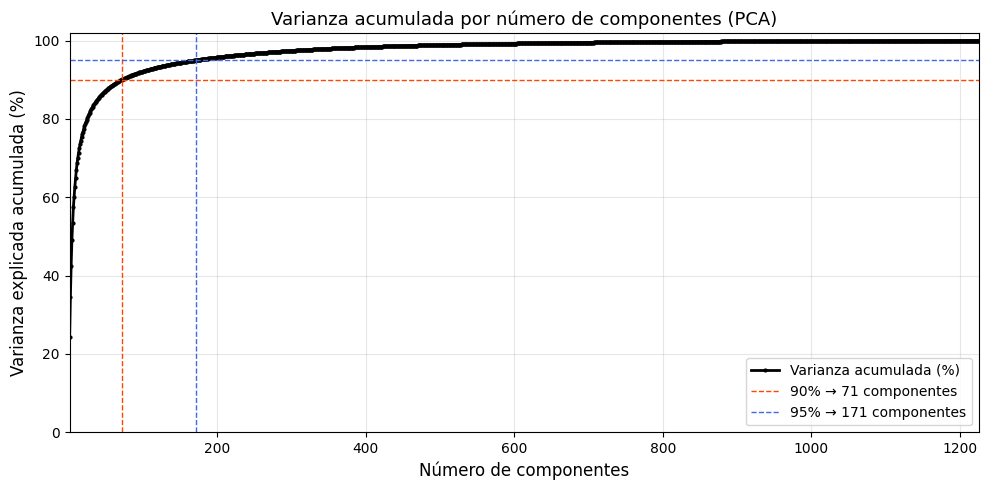

Componentes para explicar ≥ 90% de la varianza: 71


In [ ]:
# Gráfica de la varianza acumulada por cantidad de componentes

pca1 = PCA()

pca1.fit(df3)

varianza_acumulada = np.cumsum(pca1.explained_variance_ratio_) * 100
n_componentes = np.arange(1, len(varianza_acumulada) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_componentes, varianza_acumulada, marker = "o", markersize = 2,
        color = "black", linewidth = 2, label = "Varianza acumulada (%)")

for umbral in [90, 95]:

    n_opt = np.searchsorted(varianza_acumulada, umbral) + 1

    ax.axhline(y = umbral, linestyle = "--", linewidth = 1,
               color = "orangered" if umbral == 90 else "royalblue",
               label = f"{umbral}% → {n_opt} componentes")

    ax.axvline(x = n_opt, linestyle = "--", linewidth = 1,
               color = "orangered" if umbral == 90 else "royalblue")

ax.set_xlabel("Número de componentes", fontsize = 12)
ax.set_ylabel("Varianza explicada acumulada (%)", fontsize = 12)
ax.set_title("Varianza acumulada por número de componentes (PCA)", fontsize = 13)
ax.set_ylim(0, 102)
ax.set_xlim(1, len(n_componentes))
ax.legend()
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

UMBRAL = 90

n_optimo = int(np.searchsorted(varianza_acumulada, UMBRAL) + 1)

print(f"Componentes para explicar ≥ {UMBRAL}% de la varianza: {n_optimo}")

In [ ]:
# Aplicar PCA con componnetes optimos

pca = PCA(n_components = n_optimo, random_state = 42)
df_pca1 = pca.fit_transform(df1)

columnas = [f"PC{i + 1}" for i in range(n_optimo)]
df3 = pd.DataFrame(df_pca1, index = df1.index, columns = columnas)

print(df3.shape)
print(df3.head())

(15000, 71)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.481266 -0.018999 -0.844862  0.424447 -0.206010 -0.923770  0.185231   
1 -0.172076 -0.127501  0.778942  0.114500 -0.195826 -0.508679 -0.464408   
2  0.422499 -0.005036 -0.896271  0.694351 -0.220903 -0.879935  0.115414   
3  0.191583 -0.022897 -0.847494  0.251595 -0.233790 -0.980755  0.101238   
4 -0.005855 -0.032771 -1.273982 -0.323190 -0.569909 -0.295359 -0.726308   

        PC8       PC9      PC10  ...      PC62      PC63      PC64      PC65  \
0 -0.228200  0.128874  0.913181  ...  0.000267  0.027873 -0.012266  0.027318   
1 -0.075867 -0.100351 -0.006518  ... -0.018483  0.019532  0.017414 -0.015647   
2 -0.278772  0.166099  0.963558  ... -0.054548  0.019786 -0.008758 -0.016436   
3 -0.305723  0.156674  1.048122  ... -0.022144  0.018317 -0.003118 -0.004013   
4 -0.267471 -0.120211 -0.953465  ... -0.057244  0.037148 -0.089355  0.024455   

       PC66      PC67      PC68      PC69      PC70     

**df3: Dataset imputado, normalizado, codificado y transformado con PCA con componentes más relevantes**

# 9.1. Ajuste de Hiperparámetros para df3 para K-Means, Agglomeartive Cluster y DBSCAN

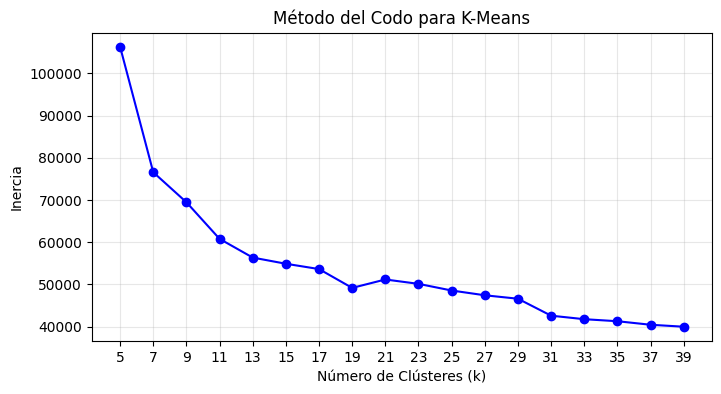

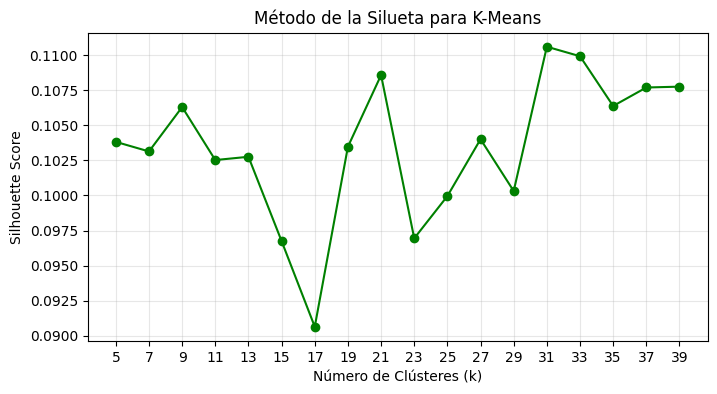


Parámetros óptimos elegidos: n_clusters = 6
Inercia con k = 6: 103480.888429613
Silhouette Score con k = 6: 0.10378047636940466


In [ ]:
# 1. Ajuste de hiperparámetros para K-Means en df3

# Rango de clústeres a probar

k_range = range(5, 41, 2)

inertia = []
silhouette_scores = []

for k in k_range:

    kmeans = KMeans(n_clusters = k, n_init = 'auto', random_state = 42)

    kmeans.fit(df3)

    inertia.append(kmeans.inertia_)
    labels = kmeans.labels_

    silhouette_scores.append(silhouette_score(df3, labels))

# 2. Gráfica del codo y la rodilla

plt.figure(figsize = (8, 4))

plt.plot(k_range, inertia, marker = 'o', color = 'blue')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K-Means')
plt.xticks(k_range)
plt.grid(True, alpha = 0.3)
plt.show()

plt.figure(figsize = (8, 4))

plt.plot(k_range, silhouette_scores, marker = 'o', color = 'green')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta para K-Means')
plt.xticks(k_range)
plt.grid(True, alpha = 0.3)
plt.show()

# 3. Elegir los parámetros óptimos y ejecutar KMeans

optimal_k = 6
kmeans_optimal = KMeans(n_clusters = optimal_k, n_init = 'auto', random_state = 42)

kmeans_optimal.fit(df3)

optimal_inertia = kmeans_optimal.inertia_
optimal_silhouette_score = silhouette_score(df3, kmeans_optimal.labels_)

print(f"\nParámetros óptimos elegidos: n_clusters = {optimal_k}")
print(f"Inercia con k = {optimal_k}: {optimal_inertia}")
print(f"Silhouette Score con k = {optimal_k}: {optimal_silhouette_score}")


In [ ]:
# 2. Ajuste de hiperparámetros para Agglomerative Clustering en df3

# Rango de clústeres a probar

k_range = range(5, 41, 2)

silhouette_scores_agg = []

for k in k_range:

    agg_model = AgglomerativeClustering(n_clusters = k)

    labels = agg_model.fit_predict(df3)

    score = silhouette_score(df3, labels)
    silhouette_scores_agg.append(score)

    print(f"Clusters: {k} | Silhouette Score: {score:.4f}")

# 2. Elegir los parámetros óptimos y ejecutar AgglomerativeClustering

optimal_k_agg = 6

agg_optimal = AgglomerativeClustering(n_clusters = optimal_k_agg)
agg_labels = agg_optimal.fit_predict(df3)

final_silhouette_agg = silhouette_score(df3, agg_labels)

print(f"\nParámetros óptimos elegidos: n_clusters = {optimal_k_agg}")
print(f"Silhouette Score con k = {optimal_k_agg}: {final_silhouette_agg}")

Clusters: 5 | Silhouette Score: 0.1031
Clusters: 7 | Silhouette Score: 0.1033
Clusters: 9 | Silhouette Score: 0.0681
Clusters: 11 | Silhouette Score: 0.0713
Clusters: 13 | Silhouette Score: 0.0680
Clusters: 15 | Silhouette Score: 0.0682
Clusters: 17 | Silhouette Score: 0.0779
Clusters: 19 | Silhouette Score: 0.0770
Clusters: 21 | Silhouette Score: 0.0768
Clusters: 23 | Silhouette Score: 0.0806
Clusters: 25 | Silhouette Score: 0.0852
Clusters: 27 | Silhouette Score: 0.0603
Clusters: 29 | Silhouette Score: 0.0629
Clusters: 31 | Silhouette Score: 0.0586
Clusters: 33 | Silhouette Score: 0.0635
Clusters: 35 | Silhouette Score: 0.0689
Clusters: 37 | Silhouette Score: 0.0740
Clusters: 39 | Silhouette Score: 0.0773

Parámetros óptimos elegidos: n_clusters = 6
Silhouette Score con k = 6: 0.10322393068244468


In [ ]:
# 3. Ajuste de hiperparámetros para DBSCAN en df3

# Definir rangos para eps y min_samples

eps_range = [0.1, 0.3, 0.5, 0.7, 1.0]
min_samples_range = [5, 10, 20, 50]

resultados_dbscan = []

# Generar combinaciones

combinaciones = list(itertools.product(eps_range, min_samples_range))

print("Iniciando búsqueda de parámetros para DBSCAN...")

for eps, min_samples in combinaciones:

    dbscan = DBSCAN(eps = eps, min_samples = min_samples)

    labels = dbscan.fit_predict(df3)

    # Contar clústeres (excluyendo el ruido etiquetado como -1)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # El Silhouettee Scroe requiere al menos 2 clústeres

    if n_clusters > 1:

        score = silhouette_score(df3, labels)
        resultados_dbscan.append((eps, min_samples, n_clusters, score))

        print(f"eps: {eps} | min_samples: {min_samples} | Clusters: {n_clusters} | Silhouette: {score:.4f}")

# 2. Elegir la mejor combinación

if resultados_dbscan:

    mejor_resultado = max(resultados_dbscan, key=lambda x: x[3])
    best_eps, best_min_samples, best_n_clusters, best_score = mejor_resultado

    print("\n--- Mejor combinación encontrada ---")

    print(f"Epsilon (eps): {best_eps}")
    print(f"Min Samples: {best_min_samples}")
    print(f"Número de clústeres detectados: {best_n_clusters}")
    print(f"Silhouette Score: {best_score:.4f}")

else:

    print("\nNo se encontraron combinaciones que generen más de un clúster. Intenta ampliar el rango de 'eps'.")

Iniciando búsqueda de parámetros para DBSCAN...
eps: 0.1 | min_samples: 5 | Clusters: 253 | Silhouette: -0.2440
eps: 0.1 | min_samples: 10 | Clusters: 91 | Silhouette: -0.2754
eps: 0.1 | min_samples: 20 | Clusters: 22 | Silhouette: -0.2326
eps: 0.1 | min_samples: 50 | Clusters: 3 | Silhouette: -0.1254
eps: 0.3 | min_samples: 5 | Clusters: 440 | Silhouette: -0.1038
eps: 0.3 | min_samples: 10 | Clusters: 141 | Silhouette: -0.2216
eps: 0.3 | min_samples: 20 | Clusters: 39 | Silhouette: -0.2617
eps: 0.3 | min_samples: 50 | Clusters: 5 | Silhouette: -0.1231
eps: 0.5 | min_samples: 5 | Clusters: 493 | Silhouette: -0.0535
eps: 0.5 | min_samples: 10 | Clusters: 173 | Silhouette: -0.1914
eps: 0.5 | min_samples: 20 | Clusters: 47 | Silhouette: -0.2493
eps: 0.5 | min_samples: 50 | Clusters: 6 | Silhouette: -0.1730
eps: 0.7 | min_samples: 5 | Clusters: 518 | Silhouette: -0.0352
eps: 0.7 | min_samples: 10 | Clusters: 185 | Silhouette: -0.1763
eps: 0.7 | min_samples: 20 | Clusters: 56 | Silhouette: 

# 10.0.  Prueba: Dataset de Embeddings con PCA

In [ ]:
df4 = df2.copy()

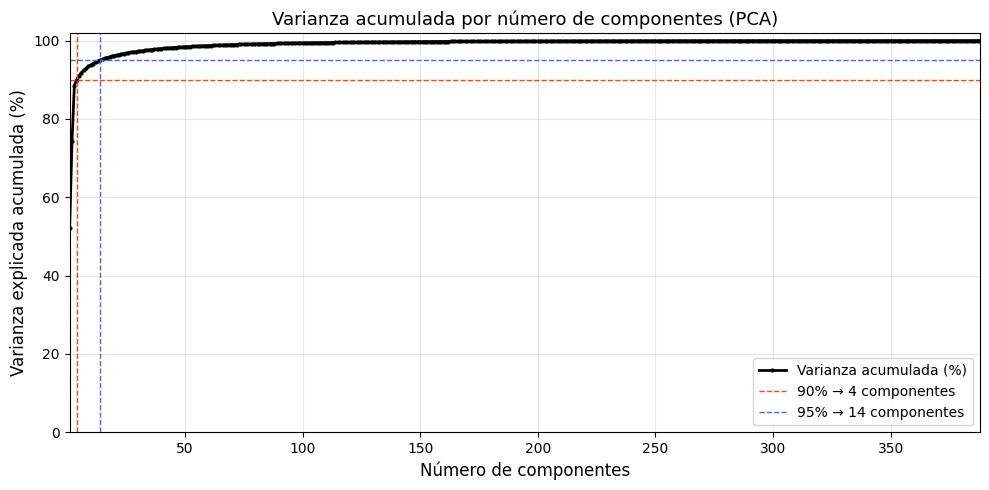

Componentes para explicar ≥ 90% de la varianza: 4


In [ ]:
# Gráfica de la varianza acumulada por cantidad de componentes

pca2 = PCA()

pca2.fit(df4)

varianza_acumulada = np.cumsum(pca2.explained_variance_ratio_) * 100
n_componentes = np.arange(1, len(varianza_acumulada) + 1)

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(n_componentes, varianza_acumulada, marker = "o", markersize = 2,
        color = "black", linewidth = 2, label = "Varianza acumulada (%)")

for umbral in [90, 95]:

    n_opt = np.searchsorted(varianza_acumulada, umbral) + 1

    ax.axhline(y = umbral, linestyle = "--", linewidth = 1,
               color = "orangered" if umbral == 90 else "royalblue",
               label = f"{umbral}% → {n_opt} componentes")

    ax.axvline(x = n_opt, linestyle = "--", linewidth = 1,
               color = "orangered" if umbral == 90 else "royalblue")

ax.set_xlabel("Número de componentes", fontsize = 12)
ax.set_ylabel("Varianza explicada acumulada (%)", fontsize = 12)
ax.set_title("Varianza acumulada por número de componentes (PCA)", fontsize = 13)
ax.set_ylim(0, 102)
ax.set_xlim(1, len(n_componentes))
ax.legend()
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

UMBRAL = 90

n_optimo2 = int(np.searchsorted(varianza_acumulada, UMBRAL) + 1)

print(f"Componentes para explicar ≥ {UMBRAL}% de la varianza: {n_optimo2}")

In [ ]:
# Aplicar PCA con componnetes optimos al dataset de embeddings

pca2 = PCA(n_components = n_optimo2, random_state = 42)
df_pca2 = pca2.fit_transform(df4)

columnas = [f"PC{i + 1}" for i in range(n_optimo2)]
df4 = pd.DataFrame(df_pca2, index = df2.index, columns = columnas)

print(df4.shape)
print(df4.head())

(15000, 4)
        PC1       PC2       PC3       PC4
0  0.468029 -0.054147  0.516752 -0.067538
1 -0.158430 -0.073957 -0.127504 -0.072890
2  0.409521 -0.042772  0.790554 -0.020613
3  0.176309 -0.059370  0.337638 -0.014765
4 -0.024662 -0.067552  0.045341  0.587050


**df4: Dataset imputado, normalizado, con embeddings y transformado con PCA con componentes más relevantes**

# 10.1. Ajuste de Hiperparámetros para df4 para K-Means, Agglomeartive Cluster y DBSCAN

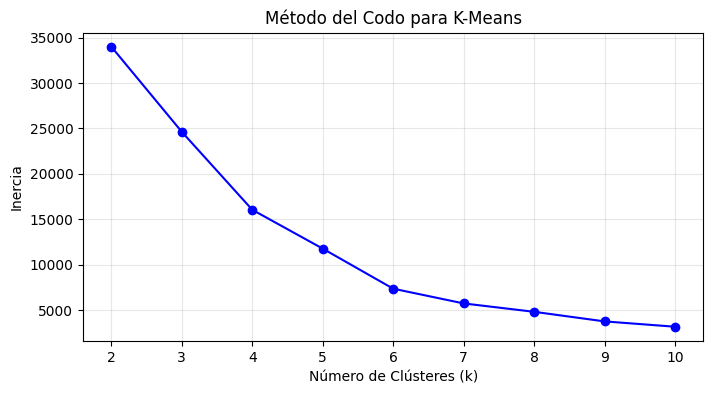

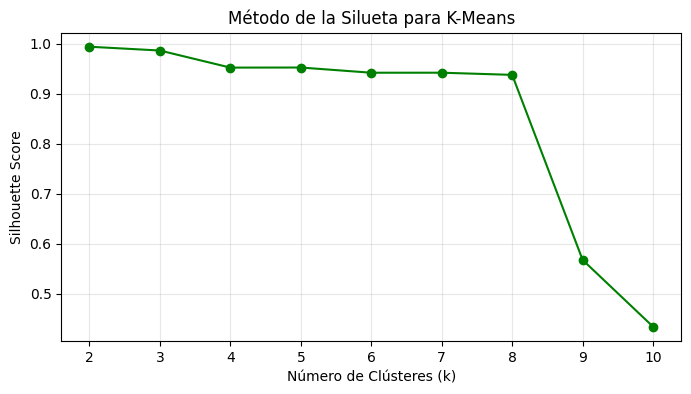


Parámetros óptimos elegidos: n_clusters = 6
Inercia con k = 6: 7338.6126980681
Silhouette Score con k = 6: 0.9422944357888347


In [ ]:
# 1. Ajuste de hiperparámetros para K-Means en df4

# Rango de clústeres a probar

k_range = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_range:

    kmeans = KMeans(n_clusters = k, n_init = 'auto', random_state = 42)

    kmeans.fit(df4)

    inertia.append(kmeans.inertia_)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(df4, labels))

# 2. Gráfica del codo y la rodilla

plt.figure(figsize = (8, 4))

plt.plot(k_range, inertia, marker = 'o', color = 'blue')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K-Means')
plt.xticks(k_range)
plt.grid(True, alpha = 0.3)
plt.show()

plt.figure(figsize = (8, 4))

plt.plot(k_range, silhouette_scores, marker = 'o', color = 'green')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta para K-Means')
plt.xticks(k_range)
plt.grid(True, alpha = 0.3)
plt.show()

# 3. Elegir los parámetros óptimos y ejecutar KMeans

optimal_k = 6
kmeans_optimal = KMeans(n_clusters = optimal_k, n_init = 'auto', random_state = 42)
kmeans_optimal.fit(df4)

optimal_inertia = kmeans_optimal.inertia_
optimal_silhouette_score = silhouette_score(df4, kmeans_optimal.labels_)

print(f"\nParámetros óptimos elegidos: n_clusters = {optimal_k}")
print(f"Inercia con k = {optimal_k}: {optimal_inertia}")
print(f"Silhouette Score con k = {optimal_k}: {optimal_silhouette_score}")

In [ ]:
# 2. Ajuste de hiperparámetros para Agglomerative Clustering en df4

# Rango de clústeres a probar

k_range = range(2, 11)

silhouette_scores_agg = []

for k in k_range:

    agg_model = AgglomerativeClustering(n_clusters = k)

    labels = agg_model.fit_predict(df4)

    score = silhouette_score(df4, labels)
    silhouette_scores_agg.append(score)

    print(f"Clusters: {k} | Silhouette Score: {score:.4f}")

# 2. Elegir los parámetros óptimos y ejecutar AgglomerativeClustering

optimal_k_agg = 6

agg_optimal = AgglomerativeClustering(n_clusters = optimal_k_agg)
agg_labels = agg_optimal.fit_predict(df4)

final_silhouette_agg = silhouette_score(df4, agg_labels)

print(f"\nParámetros óptimos elegidos: n_clusters = {optimal_k_agg}")
print(f"Silhouette Score con k = {optimal_k_agg}: {final_silhouette_agg}")

Clusters: 2 | Silhouette Score: 0.9922
Clusters: 3 | Silhouette Score: 0.9862
Clusters: 4 | Silhouette Score: 0.9262
Clusters: 5 | Silhouette Score: 0.9220
Clusters: 6 | Silhouette Score: 0.9222
Clusters: 7 | Silhouette Score: 0.8884
Clusters: 8 | Silhouette Score: 0.8885
Clusters: 9 | Silhouette Score: 0.6405
Clusters: 10 | Silhouette Score: 0.6406

Parámetros óptimos elegidos: n_clusters = 6
Silhouette Score con k = 6: 0.9221898471826278


In [ ]:
# 3. Ajuste de hiperparámetros para DBSCAN en df4

# Definir rangos para eps y min_samples

eps_range = [0.1, 0.3, 0.5, 0.7, 1.0]
min_samples_range = [5, 10, 20]

resultados_dbscan = []

# Generar combinaciones

combinaciones = list(itertools.product(eps_range, min_samples_range))

print("Iniciando búsqueda de parámetros para DBSCAN...")

for eps, min_samples in combinaciones:

    dbscan = DBSCAN(eps = eps, min_samples = min_samples)

    labels = dbscan.fit_predict(df4)

    # Contar clústeres (excluyendo el ruido etiquetado como -1)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # El Silhouette Score requiere al menos 2 clústeres

    if n_clusters > 1:

        score = silhouette_score(df4, labels)
        resultados_dbscan.append((eps, min_samples, n_clusters, score))

        print(f"eps: {eps} | min_samples: {min_samples} | Clusters: {n_clusters} | Silhouette: {score:.4f}")

# 2. Elegir la mejor combinación

if resultados_dbscan:

    mejor_resultado = max(resultados_dbscan, key = lambda x: x[3])
    best_eps, best_min_samples, best_n_clusters, best_score = mejor_resultado

    print("\n--- Mejor combinación encontrada ---")

    print(f"Epsilon (eps): {best_eps}")
    print(f"Min Samples: {best_min_samples}")
    print(f"Número de clústeres detectados: {best_n_clusters}")
    print(f"Silhouette Score: {best_score:.4f}")

else:

    print("\nNo se encontraron combinaciones que generen más de un clúster. Intenta ampliar el rango de 'eps'.")

Iniciando búsqueda de parámetros para DBSCAN...
eps: 0.1 | min_samples: 5 | Clusters: 16 | Silhouette: 0.2975
eps: 0.1 | min_samples: 10 | Clusters: 7 | Silhouette: 0.4265
eps: 0.1 | min_samples: 20 | Clusters: 3 | Silhouette: 0.2601
eps: 0.3 | min_samples: 5 | Clusters: 11 | Silhouette: 0.4228
eps: 0.3 | min_samples: 10 | Clusters: 5 | Silhouette: 0.6688
eps: 0.3 | min_samples: 20 | Clusters: 2 | Silhouette: 0.8127
eps: 0.5 | min_samples: 5 | Clusters: 8 | Silhouette: 0.6842
eps: 0.5 | min_samples: 10 | Clusters: 7 | Silhouette: 0.6816
eps: 0.5 | min_samples: 20 | Clusters: 4 | Silhouette: 0.8177
eps: 0.7 | min_samples: 5 | Clusters: 5 | Silhouette: 0.9014
eps: 0.7 | min_samples: 10 | Clusters: 5 | Silhouette: 0.8710
eps: 0.7 | min_samples: 20 | Clusters: 3 | Silhouette: 0.9001
eps: 1.0 | min_samples: 5 | Clusters: 5 | Silhouette: 0.9017
eps: 1.0 | min_samples: 10 | Clusters: 4 | Silhouette: 0.9010
eps: 1.0 | min_samples: 20 | Clusters: 3 | Silhouette: 0.9002

--- Mejor combinación en

# 11.0. Prueba: Dataset de Embeddings con PCA

In [32]:
df5 = df2.copy()

# 11.1. Ajuste Conjunto de Hiperparámetros para df5 para UMAP y ajuste de K-Means, Agglomeartive Cluster y DBSCAN

In [ ]:
# 1. K-Means: Ajuste de Hiperparámetros UMAP con Silhoutte Score

resultados = []

# Rangos

n_components_range = [10, 20, 40, 80]
n_neighbors_range = [10, 30, 60, 100]
min_dist_range = [0.1, 0.3, 0.5]
clusters_range = [15, 35, 55]

# Generar todas las combinaciones posibles

combinaciones = list(itertools.product(n_components_range, n_neighbors_range, min_dist_range, clusters_range))

for components, neighbors, min_dist, clusters in tqdm(combinaciones, desc = "Optimizando UMAP"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42,
    )

    X_umap = reducer.fit_transform(df5)

    # Evaluación mediante KMeans y Silhouette Score

    labels = KMeans(n_clusters = clusters, n_init = 'auto', random_state = 42).fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)

    resultados.append((components, neighbors, min_dist, clusters, score))

# El score está en el índice 4

resultados = sorted(resultados, key = lambda x: x[4], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette_score):")

for res in resultados[:5]:

    print(res)

Optimizando UMAP:   0%|          | 0/144 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette_score):
(40, 30, 0.1, 35, np.float32(0.60301024))
(20, 30, 0.1, 55, np.float32(0.5915238))
(40, 30, 0.1, 55, np.float32(0.5896991))
(80, 30, 0.1, 35, np.float32(0.5880853))
(20, 100, 0.1, 55, np.float32(0.5810251))


In [ ]:
# 2. Agglomerative Clustering: Ajuste de Hiperparámetros UMAP con Silhoutte Score

resultados = []

# Rangos

n_components_range = [10, 20, 40, 80]
n_neighbors_range = [10, 30, 60, 100]
min_dist_range = [0.1, 0.3, 0.5]
clusters_range = [15, 35, 55]

combinaciones = list(itertools.product(
    n_components_range,
    n_neighbors_range,
    min_dist_range,
    clusters_range
))

for components, neighbors, min_dist, clusters in tqdm(combinaciones, desc = "UMAP + Agglomerative"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42
    )

    X_umap = reducer.fit_transform(df5)

    # Agglomerative

    model = AgglomerativeClustering(
        n_clusters = clusters,
        linkage = 'ward'
    )

    labels = model.fit_predict(X_umap)

    score = silhouette_score(X_umap, labels)

    resultados.append((components, neighbors, min_dist, clusters, score))

resultados = sorted(resultados, key = lambda x: x[4], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette):")

for res in resultados[:5]:

    print(res)

UMAP + Agglomerative:   0%|          | 0/144 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette):
(80, 60, 0.1, 35, np.float32(0.60273385))
(40, 60, 0.1, 35, np.float32(0.59969646))
(20, 30, 0.1, 35, np.float32(0.59679204))
(40, 30, 0.1, 35, np.float32(0.5938792))
(80, 30, 0.1, 55, np.float32(0.58861154))


In [33]:
# 3. DBSCAN: Ajuste de Hiperparámetros UMAP con Silhoutte Score

resultados = []

# Rangos

n_components_range = [20, 65, 100]
n_neighbors_range = [30, 60, 100]
min_dist_range = [0.25, 0.6]

eps_range = [0.5, 0.9]
min_samples_range = [15, 45]

combinaciones = list(itertools.product(
    n_components_range,
    n_neighbors_range,
    min_dist_range,
    eps_range,
    min_samples_range
))

for components, neighbors, min_dist, eps, min_samples in tqdm(combinaciones, desc = "UMAP + DBSCAN"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42
    )

    X_umap = reducer.fit_transform(df5)

    # DBSCAN

    model = DBSCAN(
        eps = eps,
        min_samples = min_samples
    )

    labels = model.fit_predict(X_umap)

    # Evitar casos invalidos

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:

        score = silhouette_score(X_umap, labels)
        resultados.append((components, neighbors, min_dist, eps, min_samples, n_clusters, score))

resultados = sorted(resultados, key = lambda x: x[-1], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, eps, min_samples, n_clusters, silhouette):")

for res in resultados[:5]:

    print(res)

UMAP + DBSCAN:   0%|          | 0/72 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, eps, min_samples, n_clusters, silhouette):
(65, 30, 0.25, 0.5, 45, 75, np.float32(0.40045998))
(65, 100, 0.25, 0.9, 45, 24, np.float32(0.38741815))
(20, 30, 0.25, 0.9, 45, 38, np.float32(0.37830678))
(20, 30, 0.25, 0.5, 45, 75, np.float32(0.37196776))
(100, 30, 0.25, 0.9, 45, 40, np.float32(0.35870275))


# 12.Prueba: Dataset Procesado con UMAP

In [20]:
df6 = df1.copy()

# 12.1. Ajuste Conjunto de Hiperparámetros para df6 para UMAP y ajuste de K-Means, Agglomeartive Cluster y DBSCAN

In [21]:
# K-Means: Ajuste de Hiperparámetros UMAP con Silhoutte Score

resultados = []

# Rangos

n_components_range = [20, 50, 100, 150]
n_neighbors_range = [30, 50, 100, 200]
min_dist_range = [0.1, 0.3, 0.5]
clusters_range = [15, 35, 55]

# Generar todas las combinaciones posibles

combinaciones = list(itertools.product(n_components_range, n_neighbors_range, min_dist_range, clusters_range))

for components, neighbors, min_dist, clusters in tqdm(combinaciones, desc = "Optimizando UMAP"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42,
    )

    X_umap = reducer.fit_transform(df6)

    # Evaluación mediante KMeans y Silhouette Score

    labels = KMeans(n_clusters = clusters, n_init = 'auto', random_state = 42).fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)

    resultados.append((components, neighbors, min_dist, clusters, score))

# El score está en el índice 4

resultados = sorted(resultados, key = lambda x: x[4], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette_score):")

for res in resultados[:5]:

    print(res)

Optimizando UMAP:   0%|          | 0/144 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette_score):
(20, 100, 0.1, 15, np.float32(0.4630314))
(150, 100, 0.1, 15, np.float32(0.46216217))
(100, 50, 0.1, 15, np.float32(0.4466308))
(150, 200, 0.1, 15, np.float32(0.4454153))
(20, 200, 0.1, 55, np.float32(0.44176814))


In [24]:
# Agglomerative Clustering: Ajuste de Hiperparámetros UMAP con Silhoutte Score

resultados = []

# Rangos

n_components_range = [20, 100, 150]
n_neighbors_range = [30, 100, 200]
min_dist_range = [0.1, 0.3, 0.5]
clusters_range = [15, 55]

combinaciones = list(itertools.product(
    n_components_range,
    n_neighbors_range,
    min_dist_range,
    clusters_range
))

for components, neighbors, min_dist, clusters in tqdm(combinaciones, desc = "UMAP + Agglomerative"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42
    )

    X_umap = reducer.fit_transform(df6)

    # Agglomerative

    model = AgglomerativeClustering(
        n_clusters = clusters,
        linkage = 'ward'
    )

    labels = model.fit_predict(X_umap)

    score = silhouette_score(X_umap, labels)

    resultados.append((components, neighbors, min_dist, clusters, score))

resultados = sorted(resultados, key = lambda x: x[4], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette):")

for res in resultados[:5]:

    print(res)

UMAP + Agglomerative:   0%|          | 0/54 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, n_clusters, silhouette):
(100, 100, 0.1, 15, np.float32(0.489269))
(20, 100, 0.1, 15, np.float32(0.47420627))
(20, 200, 0.1, 15, np.float32(0.45026717))
(150, 200, 0.1, 15, np.float32(0.45000768))
(100, 200, 0.1, 15, np.float32(0.4424785))


In [23]:
# Ajuste de Hiperparámetros UMAP + DBSCAN

resultados = []

# Rangos

n_components_range = [20, 100, 150]
n_neighbors_range = [30, 100, 200]
min_dist_range = [0.1, 0.3, 0.5]

eps_range = [0.7, 2.5]
min_samples_range = [20, 80]

combinaciones = list(itertools.product(
    n_components_range,
    n_neighbors_range,
    min_dist_range,
    eps_range,
    min_samples_range
))

for components, neighbors, min_dist, eps, min_samples in tqdm(combinaciones, desc="UMAP + DBSCAN"):

    reducer = umap.UMAP(
        n_components = components,
        n_neighbors = neighbors,
        min_dist = min_dist,
        random_state = 42
    )

    X_umap = reducer.fit_transform(df6)

    # DBSCAN

    model = DBSCAN(
        eps = eps,
        min_samples = min_samples
    )

    labels = model.fit_predict(X_umap)

    # Evitar casos invalidos

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters > 1:

        score = silhouette_score(X_umap, labels)
        resultados.append((components, neighbors, min_dist, eps, min_samples, n_clusters, score))

resultados = sorted(resultados, key = lambda x: x[-1], reverse = True)

print("\nMejores resultados (n_components, n_neighbors, min_dist, eps, min_samples, n_clusters, silhouette):")

for res in resultados[:5]:

    print(res)

UMAP + DBSCAN:   0%|          | 0/108 [00:00<?, ?it/s]


Mejores resultados (n_components, n_neighbors, min_dist, eps, min_samples, n_clusters, silhouette):
(20, 200, 0.5, 2.5, 20, 5, np.float32(0.82049227))
(20, 200, 0.5, 2.5, 80, 5, np.float32(0.82049227))
(100, 200, 0.5, 2.5, 20, 5, np.float32(0.8125366))
(100, 200, 0.5, 2.5, 80, 5, np.float32(0.8125366))
(150, 200, 0.5, 2.5, 20, 5, np.float32(0.8100723))
